In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import jax.numpy as jnp

from pymcsimmod import Jax_Model, Scipy_Model

In [2]:
filename = Path("../../tests/data/pred_prey.model")
assert filename.exists()
print(filename.absolute().resolve())

/data/tzurlind/Desktop/PKWG/PyMCSimMod/tests/data/pred_prey.model


# Run an ODEint model

In [3]:
scipy_model = Scipy_Model()
scipy_model.from_model(path=filename)
times = np.linspace(0, 50, 500)
solution = scipy_model.run_model(times)

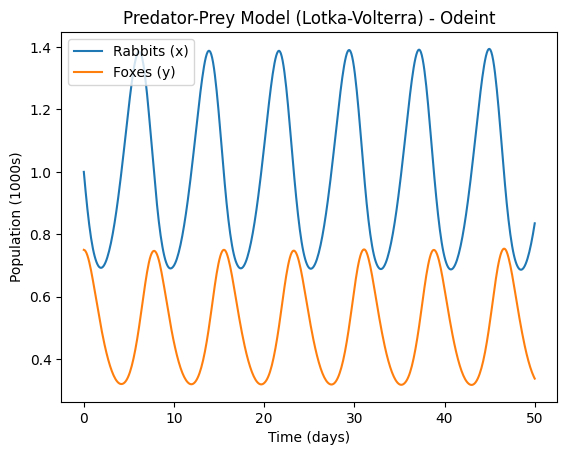

In [4]:
plt.plot(solution.t, solution.y[0], label="Rabbits (x)")
plt.plot(solution.t, solution.y[1], label="Foxes (y)")
plt.xlabel("Time (days)")
plt.ylabel("Population (1000s)")
plt.legend()
plt.title("Predator-Prey Model (Lotka-Volterra) - Odeint")
plt.show()

# Run a jax model

Currently not working

In [43]:
jax_model = Jax_Model()
jax_model.from_model(path=filename)
jax_model.update_Y0(x = 2)
times = np.linspace(0, 50, 500)
solution = jax_model.run_model(times)

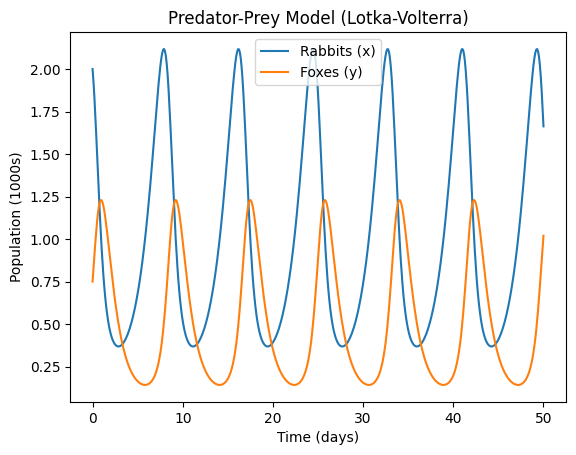

In [44]:
# Plot the results
plt.plot(solution.ts, solution.ys[:, 0], label="Rabbits (x)")
plt.plot(solution.ts, solution.ys[:, 1], label="Foxes (y)")
plt.xlabel("Time (days)")
plt.ylabel("Population (1000s)")
plt.legend()
plt.title("Predator-Prey Model (Lotka-Volterra)")
plt.show()